In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Ready")

Ready


In [2]:
# Load SPY daily data for execution simulation
df = yf.download("SPY", start="2023-01-01",
                  end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)

# Use one specific day for our execution example
# Pick a typical trading day
trade_date = "2023-06-01"
day_data = df.loc[trade_date]

open_price  = float(day_data["Open"])
high_price  = float(day_data["High"])
low_price   = float(day_data["Low"])
close_price = float(day_data["Close"])
volume      = float(day_data["Volume"])

print(f"Execution simulation for SPY on {trade_date}")
print(f"{'='*45}")
print(f"  Open  : ${open_price:.2f}")
print(f"  High  : ${high_price:.2f}")
print(f"  Low   : ${low_price:.2f}")
print(f"  Close : ${close_price:.2f}")
print(f"  Volume: {volume:,.0f} shares")
print(f"{'='*45}")

# Order parameters
order_shares = 10000  # We want to buy 10,000 shares
order_value  = order_shares * open_price
print(f"\nOrder: BUY {order_shares:,} shares")
print(f"Order value: ${order_value:,.2f}")
print(f"% of daily volume: {order_shares/volume:.2%}")

[*********************100%***********************]  1 of 1 completed

Execution simulation for SPY on 2023-06-01
  Open  : $401.30
  High  : $405.93
  Low   : $400.05
  Close : $404.88
  Volume: 88,865,000 shares

Order: BUY 10,000 shares
Order value: $4,012,966.13
% of daily volume: 0.01%


In [3]:
# Simulate intraday price path
# SPY trades from 9:30 AM to 4:00 PM = 390 minutes
np.random.seed(42)
n_minutes = 390
trading_hours = pd.date_range(
    start=f"{trade_date} 09:30",
    periods=n_minutes,
    freq="1min"
)

# Simulate minute-by-minute prices using GBM
daily_vol  = 0.01  # ~1% daily vol for SPY
minute_vol = daily_vol / np.sqrt(390)
returns    = np.random.normal(0, minute_vol, n_minutes)

# Start at open, end near close
drift = np.log(close_price/open_price) / n_minutes
intraday_prices = open_price * np.exp(
    np.cumsum(drift + returns))
intraday_prices[0]    = open_price
intraday_prices[-1]   = close_price
price_series = pd.Series(intraday_prices, index=trading_hours)

# Build TWAP schedule
def twap_schedule(total_shares, n_slices, price_series):
    """
    Split order into equal time slices.
    Returns DataFrame with schedule and execution details.
    """
    slice_size  = total_shares // n_slices
    remainder   = total_shares % n_slices
    interval    = len(price_series) // n_slices
    schedule    = []

    for i in range(n_slices):
        idx         = i * interval
        shares      = slice_size + (remainder if i==0 else 0)
        exec_price  = price_series.iloc[idx]
        exec_time   = price_series.index[idx]
        schedule.append({
            "slice"     : i+1,
            "time"      : exec_time,
            "shares"    : shares,
            "price"     : exec_price,
            "value"     : shares * exec_price
        })

    df_sched = pd.DataFrame(schedule)
    avg_price = (df_sched['value'].sum() /
                 df_sched['shares'].sum())
    return df_sched, avg_price

# Run TWAP with 12 slices (every 30 minutes)
twap_df, twap_avg = twap_schedule(
    order_shares, 12, price_series)

print("TWAP EXECUTION SCHEDULE")
print("=" * 55)
print(f"  {'Slice':>5} {'Time':>8} {'Shares':>8} {'Price':>9} {'Value':>12}")
print("-" * 55)
for _, row in twap_df.iterrows():
    t = row['time'].strftime('%H:%M')
    print(f"  {int(row['slice']):>5} {t:>8} {int(row['shares']):>8} "
          f"${row['price']:>8.2f} ${row['value']:>11,.2f}")
print("=" * 55)
print(f"  TWAP avg execution price: ${twap_avg:.2f}")
print(f"  Open price (naive):       ${open_price:.2f}")
print(f"  Implementation shortfall: "
      f"{(twap_avg-open_price)/open_price:.4%}")

TWAP EXECUTION SCHEDULE
  Slice     Time   Shares     Price        Value
-------------------------------------------------------
      1    09:30      837 $  401.30 $ 335,885.26
      2    10:02      833 $  400.70 $ 333,785.65
      3    10:34      833 $  399.57 $ 332,842.58
      4    11:06      833 $  400.07 $ 333,256.96
      5    11:38      833 $  400.79 $ 333,857.90
      6    12:10      833 $  400.37 $ 333,510.81
      7    12:42      833 $  401.91 $ 334,793.06
      8    13:14      833 $  403.23 $ 335,890.87
      9    13:46      833 $  403.95 $ 336,492.60
     10    14:18      833 $  403.35 $ 335,991.27
     11    14:50      833 $  405.05 $ 337,405.39
     12    15:22      833 $  405.07 $ 337,420.27
  TWAP avg execution price: $402.11
  Open price (naive):       $401.30
  Implementation shortfall: 0.2035%


In [4]:
# Build VWAP schedule using U-shaped volume profile
def vwap_schedule(total_shares, price_series, n_slices=12):
    """
    Schedule execution proportional to intraday volume profile.
    U-shaped: heavy at open and close, light midday.
    """
    # U-shaped volume profile for 12 time slices
    volume_profile = np.array([
        0.15, 0.10, 0.07, 0.06, 0.05,
        0.05, 0.06, 0.07, 0.08, 0.10,
        0.10, 0.11
    ])
    volume_profile = volume_profile / volume_profile.sum()

    interval = len(price_series) // n_slices
    schedule = []

    for i in range(n_slices):
        idx        = i * interval
        shares     = int(total_shares * volume_profile[i])
        exec_price = price_series.iloc[idx]
        exec_time  = price_series.index[idx]
        schedule.append({
            "slice"     : i+1,
            "time"      : exec_time,
            "shares"    : shares,
            "pct_vol"   : volume_profile[i],
            "price"     : exec_price,
            "value"     : shares * exec_price
        })

    # Adjust last slice for rounding
    df_sched = pd.DataFrame(schedule)
    diff = total_shares - df_sched['shares'].sum()
    df_sched.loc[df_sched.index[-1], 'shares'] += diff
    df_sched['value'] = df_sched['shares'] * df_sched['price']

    avg_price = (df_sched['value'].sum() /
                 df_sched['shares'].sum())
    return df_sched, avg_price

vwap_df, vwap_avg = vwap_schedule(order_shares, price_series)

print("VWAP EXECUTION SCHEDULE")
print("=" * 60)
print(f"  {'Slice':>5} {'Time':>8} {'%Vol':>6} {'Shares':>8} "
      f"{'Price':>9} {'Value':>12}")
print("-" * 60)
for _, row in vwap_df.iterrows():
    t = row['time'].strftime('%H:%M')
    print(f"  {int(row['slice']):>5} {t:>8} "
          f"{row['pct_vol']:>6.1%} {int(row['shares']):>8} "
          f"${row['price']:>8.2f} ${row['value']:>11,.2f}")
print("=" * 60)
print(f"  VWAP avg execution price : ${vwap_avg:.2f}")
print(f"  TWAP avg execution price : ${twap_avg:.2f}")
print(f"  Open price (naive)       : ${open_price:.2f}")
print(f"  VWAP shortfall vs open   : "
      f"{(vwap_avg-open_price)/open_price:.4%}")
print(f"  TWAP shortfall vs open   : "
      f"{(twap_avg-open_price)/open_price:.4%}")

VWAP EXECUTION SCHEDULE
  Slice     Time   %Vol   Shares     Price        Value
------------------------------------------------------------
      1    09:30  15.0%     1500 $  401.30 $ 601,944.92
      2    10:02  10.0%     1000 $  400.70 $ 400,703.06
      3    10:34   7.0%      700 $  399.57 $ 279,699.64
      4    11:06   6.0%      600 $  400.07 $ 240,041.03
      5    11:38   5.0%      500 $  400.79 $ 200,394.90
      6    12:10   5.0%      500 $  400.37 $ 200,186.56
      7    12:42   6.0%      600 $  401.91 $ 241,147.46
      8    13:14   7.0%      700 $  403.23 $ 282,261.23
      9    13:46   8.0%      800 $  403.95 $ 323,162.16
     10    14:18  10.0%     1000 $  403.35 $ 403,350.86
     11    14:50  10.0%     1000 $  405.05 $ 405,048.48
     12    15:22  11.0%     1100 $  405.07 $ 445,572.98
  VWAP avg execution price : $402.35
  TWAP avg execution price : $402.11
  Open price (naive)       : $401.30
  VWAP shortfall vs open   : 0.2628%
  TWAP shortfall vs open   : 0.2035%


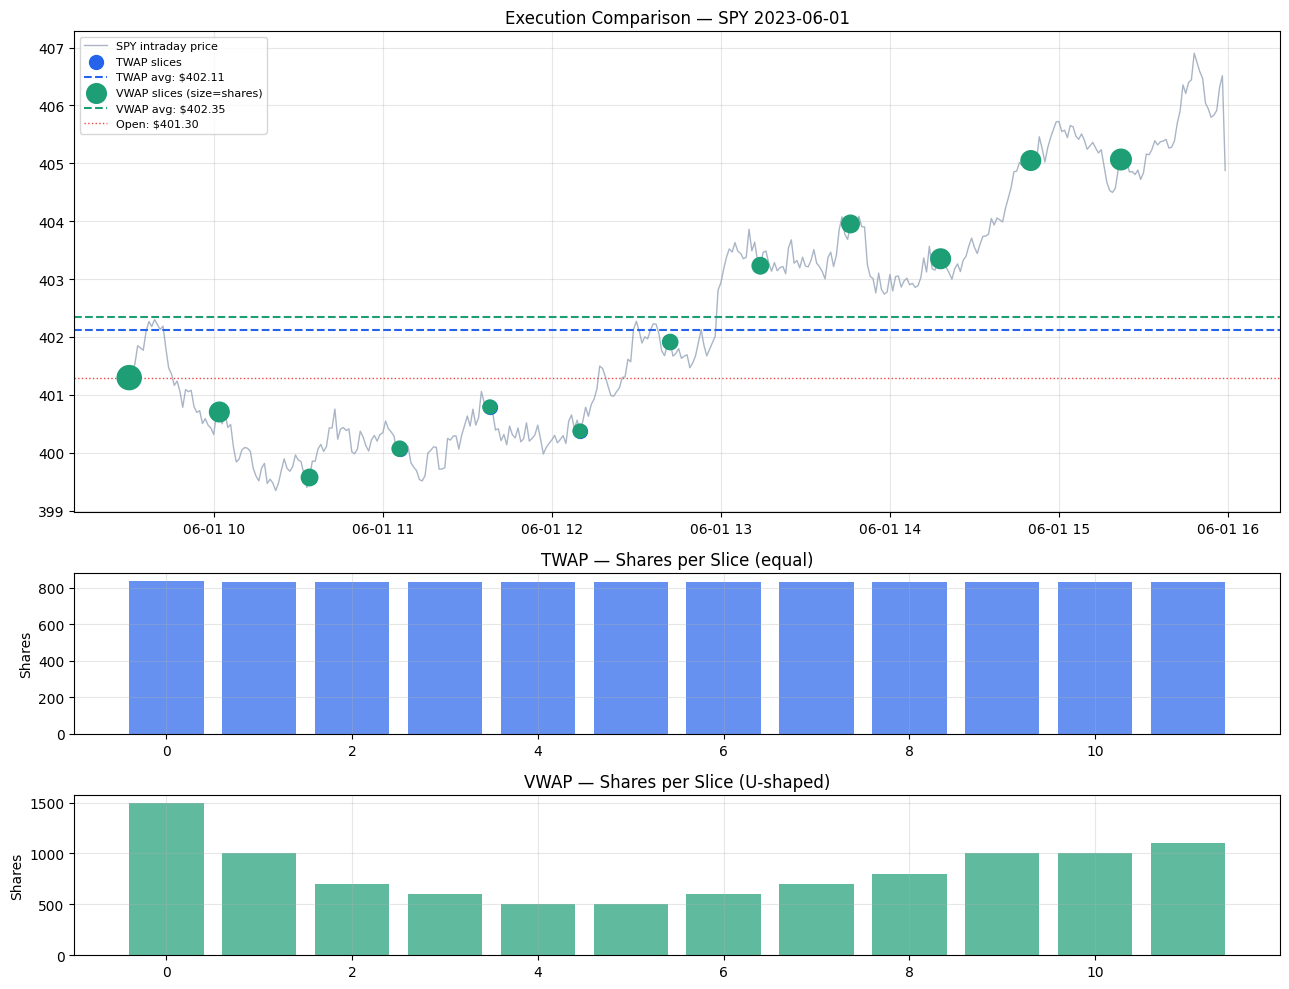


IMPLEMENTATION SHORTFALL SUMMARY
  Naive (all at open)  : $4,012,966.13
  TWAP execution       : $4,021,132.61
  VWAP execution       : $4,023,513.29
  TWAP extra cost      : $    8,166.48
  VWAP extra cost      : $   10,547.17


In [5]:
# Visualise execution schedules
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10),
    gridspec_kw={'height_ratios': [3, 1, 1]})

# Panel 1: Intraday price with execution points
ax1.plot(price_series, color='#94a3b8', lw=1,
         alpha=0.8, label='SPY intraday price')

# TWAP executions
ax1.scatter(twap_df['time'], twap_df['price'],
            color='#2563eb', s=100, zorder=5,
            label='TWAP slices')
ax1.axhline(twap_avg, color='#2563eb', lw=1.5,
            linestyle='--',
            label=f'TWAP avg: ${twap_avg:.2f}')

# VWAP executions
ax1.scatter(vwap_df['time'], vwap_df['price'],
            color='#1D9E75', s=vwap_df['shares']/5,
            zorder=5, label='VWAP slices (size=shares)')
ax1.axhline(vwap_avg, color='#1D9E75', lw=1.5,
            linestyle='--',
            label=f'VWAP avg: ${vwap_avg:.2f}')
ax1.axhline(open_price, color='#ef4444', lw=1,
            linestyle=':', label=f'Open: ${open_price:.2f}')

ax1.set_title(f'Execution Comparison — SPY {trade_date}')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: TWAP share schedule
ax2.bar(range(len(twap_df)), twap_df['shares'],
        color='#2563eb', alpha=0.7)
ax2.set_title('TWAP — Shares per Slice (equal)')
ax2.set_ylabel('Shares')
ax2.grid(True, alpha=0.3)

# Panel 3: VWAP share schedule
ax3.bar(range(len(vwap_df)), vwap_df['shares'],
        color='#1D9E75', alpha=0.7)
ax3.set_title('VWAP — Shares per Slice (U-shaped)')
ax3.set_ylabel('Shares')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Implementation shortfall summary
print("\nIMPLEMENTATION SHORTFALL SUMMARY")
print("=" * 50)
naive_cost = order_shares * open_price
twap_cost  = twap_df['value'].sum()
vwap_cost  = vwap_df['value'].sum()

print(f"  Naive (all at open)  : ${naive_cost:>12,.2f}")
print(f"  TWAP execution       : ${twap_cost:>12,.2f}")
print(f"  VWAP execution       : ${vwap_cost:>12,.2f}")
print(f"  TWAP extra cost      : ${twap_cost-naive_cost:>12,.2f}")
print(f"  VWAP extra cost      : ${vwap_cost-naive_cost:>12,.2f}")
print("=" * 50)